In [ ]:
from sparcl.client import SparclClient
client = SparclClient()
print("SPARCL client OK")

In [ ]:
found = client.find(limit=1)
print(type(found))
print("ids =", found.ids)
print("number of ids =", len(found.ids))

In [ ]:
ids = found.ids

inc = ['sparcl_id', 'flux', 'wavelength', 'model']

ret = client.retrieve(uuid_list=ids, include=inc)

print(type(ret))
print("number of records =", len(ret.records))
print("first record type =", type(ret.records[0]))

In [ ]:
rec = ret.records[0]

print("record object:", rec)
print("has wavelength:", hasattr(rec, "wavelength"))
print("has flux:", hasattr(rec, "flux"))
print("has model:", hasattr(rec, "model"))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

wave = np.array(rec.wavelength)
flux = np.array(rec.flux)

print("wave shape =", wave.shape)
print("flux shape =", flux.shape)

plt.figure(figsize=(12,4))
plt.plot(wave, flux, lw=0.8)
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.title("First public spectrum from SPARCL")
plt.tight_layout()
plt.show()

In [ ]:
inc2 = [
    'sparcl_id',
    'specid',
    'data_release',
    'redshift',
    'flux',
    'wavelength',
    'model',
    'ivar',
    'mask',
    'spectype',
    'ra',
    'dec'
]

ret2 = client.retrieve(uuid_list=ids, include=inc2)

print(type(ret2))
print("number of records =", len(ret2.records))

In [ ]:
rec2 = ret2.records[0]

print("has redshift:", hasattr(rec2, "redshift"))
print("has ivar:", hasattr(rec2, "ivar"))
print("has mask:", hasattr(rec2, "mask"))
print("has spectype:", hasattr(rec2, "spectype"))
print("has ra:", hasattr(rec2, "ra"))
print("has dec:", hasattr(rec2, "dec"))
print("has specid:", hasattr(rec2, "specid"))
print("has data_release:", hasattr(rec2, "data_release"))

In [ ]:
print("sparcl_id =", rec2.sparcl_id)

if hasattr(rec2, "specid"):
    print("specid =", rec2.specid)

if hasattr(rec2, "data_release"):
    print("data_release =", rec2.data_release)

if hasattr(rec2, "redshift"):
    print("redshift =", rec2.redshift)

if hasattr(rec2, "spectype"):
    print("spectype =", rec2.spectype)

if hasattr(rec2, "ra"):
    print("ra =", rec2.ra)

if hasattr(rec2, "dec"):
    print("dec =", rec2.dec)

In [ ]:
import numpy as np

if hasattr(rec2, "ivar"):
    ivar = np.array(rec2.ivar)
    print("ivar shape =", ivar.shape)
    print("ivar min/max =", np.nanmin(ivar), np.nanmax(ivar))

if hasattr(rec2, "mask"):
    mask = np.array(rec2.mask)
    print("mask shape =", mask.shape)
    print("unique mask values (first 20) =", np.unique(mask)[:20])

In [3]:
wave = np.array(rec2.wavelength)
flux = np.array(rec2.flux)
model = np.array(rec2.model)

plt.figure(figsize=(12,4))
plt.plot(wave, flux, lw=0.8, label="Observed spectrum")
plt.plot(wave, model, lw=1.0, label="Model")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.title("Public DESI spectrum with model")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'rec2' is not defined

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd

print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("basic packages OK")

Python: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
numpy: 1.26.3
pandas: 2.1.4
basic packages OK


In [2]:
from sparcl.client import SparclClient
client = SparclClient()
print("SPARCL client OK")

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.
SPARCL client OK


In [4]:
from dl import queryClient as qc
print("Data Lab client OK")

Data Lab client OK


In [5]:
query = """
SELECT TOP 20
    targetid,
    z,
    zwarn,
    spectype,
    mean_fiber_ra,
    mean_fiber_dec,
    healpix
FROM desi_dr1.zpix
WHERE survey = 'main'
  AND main_primary = 't'
  AND zwarn = 0
  AND spectype = 'GALAXY'
  AND z BETWEEN 0.25 AND 0.29
"""
result = qc.query(sql=query)
print(result)

targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix
39627625626339496,0.2500000426110562,0,GALAXY,221.0491993229251,-6.638262348753826,44983
39633413287708489,0.250000061842016,0,GALAXY,158.912822439167,62.16080360806118,7455
39633019929103355,0.2500000680793549,0,GALAXY,173.0202027935348,36.90546702466498,5399
39627754437612344,0.250000170598052,0,GALAXY,354.6816764788275,-1.3813050659596,18765
39627631074739726,0.2500002011432955,0,GALAXY,187.5972447553559,-6.470015779948864,25463
39627743121380006,0.2500002552538979,0,GALAXY,40.12008347866669,-1.742595954305415,17741
39628143912291198,0.2500002966559045,0,GALAXY,31.15688465937092,14.9729094683432,556
39633126175015253,0.2500003144882859,0,GALAXY,121.6084956774145,42.83104813538243,6551
39627829616315639,0.2500003228711655,0,GALAXY,155.6720913153318,1.856274657466858,27400
39627775841143396,0.2500003289611584,0,GALAXY,190.3587387081975,-0.504148047036612,26260
39628064925159414,0.2500003556451945,0,GALAXY,239.8445575603312

In [6]:
import pandas as pd
from io import StringIO

df = pd.read_csv(StringIO(result))
df.head(10)

,targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix
0,39627625626339496,0.25,0,GALAXY,221.049199,-6.638262,44983
1,39633413287708489,0.25,0,GALAXY,158.912822,62.160804,7455
2,39633019929103355,0.25,0,GALAXY,173.020203,36.905467,5399
3,39627754437612344,0.25,0,GALAXY,354.681676,-1.381305,18765
4,39627631074739726,0.25,0,GALAXY,187.597245,-6.470016,25463
5,39627743121380006,0.25,0,GALAXY,40.120083,-1.742596,17741
6,39628143912291198,0.25,0,GALAXY,31.156885,14.972909,556
7,39633126175015253,0.25,0,GALAXY,121.608496,42.831048,6551
8,39627829616315639,0.25,0,GALAXY,155.672091,1.856275,27400
9,39627775841143396,0.25,0,GALAXY,190.358739,-0.504148,26260


In [7]:
print(df.columns)
print("number of rows =", len(df))

Index(['targetid', 'z', 'zwarn', 'spectype', 'mean_fiber_ra', 'mean_fiber_dec',
       'healpix'],
      dtype='object')
number of rows = 20


In [8]:
df2 = df.copy()

# 确保 z 是数值型
df2["z"] = pd.to_numeric(df2["z"])

# 四个关键红移点
z_targets = {
    "OIII5007_to_6300": 6300/5007 - 1,
    "OIII4959_to_6300": 6300/4959 - 1,
    "OIII5007_to_6364": 6364/5007 - 1,
    "OIII4959_to_6364": 6364/4959 - 1,
}

for name, z0 in z_targets.items():
    df2[f"dz_{name}"] = abs(df2["z"] - z0)

df2

,targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz_OIII5007_to_6300,dz_OIII4959_to_6300,dz_OIII5007_to_6364,dz_OIII4959_to_6364
0,39627625626339496,0.250000,0,GALAXY,221.049199,-6.638262,44983,0.008238,0.020417,0.021021,0.033323
1,39633413287708489,0.250000,0,GALAXY,158.912822,62.160804,7455,0.008238,0.020417,0.021021,0.033323
2,39633019929103355,0.250000,0,GALAXY,173.020203,36.905467,5399,0.008238,0.020417,0.021021,0.033323
3,39627754437612344,0.250000,0,GALAXY,354.681676,-1.381305,18765,0.008238,0.020417,0.021020,0.033323
4,39627631074739726,0.250000,0,GALAXY,187.597245,-6.470016,25463,0.008238,0.020417,0.021020,0.033323
5,39627743121380006,0.250000,0,GALAXY,40.120083,-1.742596,17741,0.008238,0.020417,0.021020,0.033323
6,39628143912291198,0.250000,0,GALAXY,31.156885,14.972909,556,0.008238,0.020417,0.021020,0.033323
7,39633126175015253,0.250000,0,GALAXY,121.608496,42.831048,6551,0.008238,0.020417,0.021020,0.033323
8,39627829616315639,0.250000,0,GALAXY,155.672091,1.856275,27400,0.008238,0.020417,0.021020,0.033323
9,39627775841143396,0.250000,0,GALAXY,190.358739,-0.504148,26260,0.008238,0.020417,0.021020,0.033323


In [9]:
for name in z_targets:
    print("\n", "="*60)
    print(name)
    display(df2.sort_values(f"dz_{name}").head(3))


OIII5007_to_6300


,targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz_OIII5007_to_6300,dz_OIII4959_to_6300,dz_OIII5007_to_6364,dz_OIII4959_to_6364
19,39628054347125442,0.250001,0,GALAXY,317.444359,10.999687,12398,0.008238,0.020417,0.02102,0.033322
18,39633467100631340,0.250001,0,GALAXY,98.745571,67.488256,7858,0.008238,0.020417,0.02102,0.033322
17,39633216268668443,0.250001,0,GALAXY,181.431639,47.932217,10986,0.008238,0.020417,0.02102,0.033322



OIII4959_to_6300


,targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz_OIII5007_to_6300,dz_OIII4959_to_6300,dz_OIII5007_to_6364,dz_OIII4959_to_6364
19,39628054347125442,0.250001,0,GALAXY,317.444359,10.999687,12398,0.008238,0.020417,0.02102,0.033322
18,39633467100631340,0.250001,0,GALAXY,98.745571,67.488256,7858,0.008238,0.020417,0.02102,0.033322
17,39633216268668443,0.250001,0,GALAXY,181.431639,47.932217,10986,0.008238,0.020417,0.02102,0.033322



OIII5007_to_6364


,targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz_OIII5007_to_6300,dz_OIII4959_to_6300,dz_OIII5007_to_6364,dz_OIII4959_to_6364
19,39628054347125442,0.250001,0,GALAXY,317.444359,10.999687,12398,0.008238,0.020417,0.02102,0.033322
18,39633467100631340,0.250001,0,GALAXY,98.745571,67.488256,7858,0.008238,0.020417,0.02102,0.033322
17,39633216268668443,0.250001,0,GALAXY,181.431639,47.932217,10986,0.008238,0.020417,0.02102,0.033322



OIII4959_to_6364


,targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz_OIII5007_to_6300,dz_OIII4959_to_6300,dz_OIII5007_to_6364,dz_OIII4959_to_6364
19,39628054347125442,0.250001,0,GALAXY,317.444359,10.999687,12398,0.008238,0.020417,0.02102,0.033322
18,39633467100631340,0.250001,0,GALAXY,98.745571,67.488256,7858,0.008238,0.020417,0.02102,0.033322
17,39633216268668443,0.250001,0,GALAXY,181.431639,47.932217,10986,0.008238,0.020417,0.02102,0.033322


In [10]:
df3 = df2.copy()

df3["oiii4959_obs"] = 4959 * (1 + df3["z"])
df3["oiii5007_obs"] = 5007 * (1 + df3["z"])

df3["d_4959_to_6300"] = abs(df3["oiii4959_obs"] - 6300)
df3["d_5007_to_6300"] = abs(df3["oiii5007_obs"] - 6300)
df3["d_4959_to_6364"] = abs(df3["oiii4959_obs"] - 6364)
df3["d_5007_to_6364"] = abs(df3["oiii5007_obs"] - 6364)

display(df3[[
    "targetid", "z", "mean_fiber_ra", "mean_fiber_dec", "healpix",
    "oiii4959_obs", "oiii5007_obs",
    "d_4959_to_6300", "d_5007_to_6300",
    "d_4959_to_6364", "d_5007_to_6364"
]].head(10))

,targetid,z,mean_fiber_ra,mean_fiber_dec,healpix,oiii4959_obs,oiii5007_obs,d_4959_to_6300,d_5007_to_6300,d_4959_to_6364,d_5007_to_6364
0,39627625626339496,0.25,221.049199,-6.638262,44983,6198.750211,6258.750213,101.249789,41.249787,165.249789,105.249787
1,39633413287708489,0.25,158.912822,62.160804,7455,6198.750307,6258.750310,101.249693,41.249690,165.249693,105.249690
2,39633019929103355,0.25,173.020203,36.905467,5399,6198.750338,6258.750341,101.249662,41.249659,165.249662,105.249659
3,39627754437612344,0.25,354.681676,-1.381305,18765,6198.750846,6258.750854,101.249154,41.249146,165.249154,105.249146
4,39627631074739726,0.25,187.597245,-6.470016,25463,6198.750997,6258.751007,101.249003,41.248993,165.249003,105.248993
5,39627743121380006,0.25,40.120083,-1.742596,17741,6198.751266,6258.751278,101.248734,41.248722,165.248734,105.248722
6,39628143912291198,0.25,31.156885,14.972909,556,6198.751471,6258.751485,101.248529,41.248515,165.248529,105.248515
7,39633126175015253,0.25,121.608496,42.831048,6551,6198.751560,6258.751575,101.248440,41.248425,165.248440,105.248425
8,39627829616315639,0.25,155.672091,1.856275,27400,6198.751601,6258.751617,101.248399,41.248383,165.248399,105.248383
9,39627775841143396,0.25,190.358739,-0.504148,26260,6198.751631,6258.751647,101.248369,41.248353,165.248369,105.248353


In [11]:
z_5007_6300 = 6300/5007 - 1
z_4959_6300 = 6300/4959 - 1
z_5007_6364 = 6364/5007 - 1
z_4959_6364 = 6364/4959 - 1

print("z_5007_6300 =", z_5007_6300)
print("z_4959_6300 =", z_4959_6300)
print("z_5007_6364 =", z_5007_6364)
print("z_4959_6364 =", z_4959_6364)

z_5007_6300 = 0.25823846614739354
z_4959_6300 = 0.2704174228675136
z_5007_6364 = 0.2710205712003195
z_4959_6364 = 0.283323250655374


In [12]:
query_5007_6300 = f"""
SELECT TOP 5
    targetid,
    z,
    zwarn,
    spectype,
    mean_fiber_ra,
    mean_fiber_dec,
    healpix,
    ABS(z - ({z_5007_6300})) AS dz
FROM desi_dr1.zpix
WHERE survey = 'main'
  AND main_primary = 't'
  AND zwarn = 0
  AND spectype = 'GALAXY'
  AND z BETWEEN 0.25 AND 0.29
ORDER BY dz ASC
"""
result_5007_6300 = qc.query(sql=query_5007_6300)
print(result_5007_6300)

targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz
39628458715777850,0.2582384671244344,0,GALAXY,115.6731880661878,28.99152983915456,6243,9.770408371245765e-10
39627654655117844,0.2582384834550056,0,GALAXY,159.7951560716881,-5.539939356457634,26834,1.7307612065753375e-08
39628497672473379,0.2582384384452995,0,GALAXY,268.6502299132719,30.75958954753647,32663,2.7702094063108973e-08
39627951829942363,0.2582383385855175,0,GALAXY,256.425042666428,6.651461525453905,31215,1.2756187606211e-07
39627712553292742,0.2582385984908437,0,GALAXY,18.16734885591819,-3.026429826224952,17988,1.3234345014323523e-07



In [13]:
query_4959_6300 = f"""
SELECT TOP 5
    targetid,
    z,
    zwarn,
    spectype,
    mean_fiber_ra,
    mean_fiber_dec,
    healpix,
    ABS(z - ({z_4959_6300})) AS dz
FROM desi_dr1.zpix
WHERE survey = 'main'
  AND main_primary = 't'
  AND zwarn = 0
  AND spectype = 'GALAXY'
  AND z BETWEEN 0.25 AND 0.29
ORDER BY dz ASC
"""
result_4959_6300 = qc.query(sql=query_4959_6300)
print(result_4959_6300)

targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz
39633452709971260,0.2704174447066542,0,GALAXY,103.9210557676391,66.04651133752445,7832,2.18391406070495e-08
39627874679914711,0.2704173638765778,0,GALAXY,322.4543116243531,3.447680848057624,19170,5.8990935802860633e-08
39627739539445158,0.2704173453367865,0,GALAXY,186.7452928416774,-2.103681724190535,26247,7.753072706062625e-08
39627713203406899,0.2704175037617287,0,GALAXY,56.855129176888,-3.018152657076409,23091,8.089421510426575e-08
39628017181396531,0.2704173002582282,0,GALAXY,228.2445999630879,9.422785212785776,8294,1.226092853912064e-07



In [14]:
query_5007_6364 = f"""
SELECT TOP 5
    targetid,
    z,
    zwarn,
    spectype,
    mean_fiber_ra,
    mean_fiber_dec,
    healpix,
    ABS(z - ({z_5007_6364})) AS dz
FROM desi_dr1.zpix
WHERE survey = 'main'
  AND main_primary = 't'
  AND zwarn = 0
  AND spectype = 'GALAXY'
  AND z BETWEEN 0.25 AND 0.29
ORDER BY dz ASC
"""
result_5007_6364 = qc.query(sql=query_5007_6364)
print(result_5007_6364)

targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz
39627794463851173,0.2710205791994163,0,GALAXY,220.2803929505321,0.2508247681799297,25946,7.99909677384747e-09
39633165282706433,0.2710205576789058,0,GALAXY,102.9189982210149,45.10362793727877,6778,1.3521413710915198e-08
39628211398643627,0.2710205052554207,0,GALAXY,257.9591205331162,17.63192728097502,32315,6.594489881939225e-08
39627743641474846,0.2710205003359851,0,GALAXY,71.237924565306,-1.77573469164684,22923,7.08643344005111e-08
39627814340658738,0.2710204710267419,0,GALAXY,325.0445681227632,0.9221600142812275,19095,1.0017357759961598e-07



In [15]:
query_4959_6364 = f"""
SELECT TOP 5
    targetid,
    z,
    zwarn,
    spectype,
    mean_fiber_ra,
    mean_fiber_dec,
    healpix,
    ABS(z - ({z_4959_6364})) AS dz
FROM desi_dr1.zpix
WHERE survey = 'main'
  AND main_primary = 't'
  AND zwarn = 0
  AND spectype = 'GALAXY'
  AND z BETWEEN 0.25 AND 0.29
ORDER BY dz ASC
"""
result_4959_6364 = qc.query(sql=query_4959_6364)
print(result_4959_6364)

targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz
39628324745513579,0.2833232511954329,0,GALAXY,251.8514690057405,22.82187752834106,32443,5.400588865001055e-10
39627715711602248,0.2833232346107795,0,GALAXY,206.4005283980755,-2.980047682808293,25992,1.604459448634188e-08
39627788059149875,0.283323220592007,0,GALAXY,198.5738859577806,0.1089845383440389,26201,3.006336701805168e-08
39627848687818079,0.2833231580683649,0,GALAXY,212.4929661578154,2.544442224685314,26059,9.258700911507489e-08
39628498909794208,0.2833231119586935,0,GALAXY,354.4055359877368,30.66183856437166,20400,1.3869668052945983e-07



In [16]:
ra0 = 115.6731880661878
dec0 = 28.99152983915456
z0 = 0.2582384671244344

constraints = {
    "data_release": ["DESI-DR1"],
    "spectype": ["GALAXY"],
    "redshift": [z0 - 0.0005, z0 + 0.0005],
}

found_target = client.find(
    outfields=["id", "ra", "dec", "redshift", "spectype", "data_release"],
    constraints=constraints,
    limit=20
)

print(type(found_target))
print("ids =", found_target.ids)
print("n_ids =", len(found_target.ids))

<class 'sparcl.Results.Found'>
ids = [None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
n_ids = 20


In [17]:
for rec in found_target.records:
    print(rec)

{'redshift': 0.25811629399059927, 'spectype': 'GALAXY', 'ra': 194.41390393224484, 'data_release': 'DESI-DR1', 'dec': 26.261216666730906, '_dr': 'DESI-DR1'}
{'redshift': 0.258376428739041, 'spectype': 'GALAXY', 'ra': 86.4031617399297, 'data_release': 'DESI-DR1', 'dec': -19.596347290830206, '_dr': 'DESI-DR1'}
{'redshift': 0.258737856801007, 'spectype': 'GALAXY', 'ra': 201.31247507077714, 'data_release': 'DESI-DR1', 'dec': 2.4743104930162305, '_dr': 'DESI-DR1'}
{'redshift': 0.25862065945586654, 'spectype': 'GALAXY', 'ra': 191.72916384991638, 'data_release': 'DESI-DR1', 'dec': 26.04857430765486, '_dr': 'DESI-DR1'}
{'redshift': 0.2585241144627366, 'spectype': 'GALAXY', 'ra': 178.78754090395245, 'data_release': 'DESI-DR1', 'dec': 0.22175559789444474, '_dr': 'DESI-DR1'}
{'redshift': 0.2582769808073857, 'spectype': 'GALAXY', 'ra': 247.8727451056042, 'data_release': 'DESI-DR1', 'dec': 13.28639116455874, '_dr': 'DESI-DR1'}
{'redshift': 0.25775613192406394, 'spectype': 'GALAXY', 'ra': 272.2787538

In [18]:
ids_target = found_target.ids[:1]

ret_target = client.retrieve(
    uuid_list=ids_target,
    include=["sparcl_id", "flux", "wavelength", "model", "ivar", "mask", "redshift", "spectype", "ra", "dec"]
)

rec_target = ret_target.records[0]
print(rec_target)

C:\Users\30126\AppData\Local\Temp\ipykernel_24200\1029866574.py:3: UserWarning: Some UUIDs were not found. 1 out of the 1 requested uuids have no records available in the SPARCL database associated with DataSets {'DESI-DR1', 'DESI-EDR', 'SDSS-DR17', 'BOSS-DR17'}.Use "client.missing()" to get a list of the 1 unavailable uuids.
  ret_target = client.retrieve(


IndexError: list index out of range

In [19]:
ra0 = 115.6731880661878
dec0 = 28.99152983915456
z0 = 0.2582384671244344

constraints = {
    "data_release": ["DESI-DR1"],
    "spectype": ["GALAXY"],
    "redshift": [z0 - 0.0005, z0 + 0.0005],
}

found_target2 = client.find(
    constraints=constraints,
    limit=20
)

print(type(found_target2))
print("ids =", found_target2.ids)
print("n_ids =", len(found_target2.ids))

<class 'sparcl.Results.Found'>
ids = ['0001ebf4-88fe-11ef-9cf8-525400f334e1', '0003997a-87ad-11ef-bad1-525400f334e1', '00089022-89a5-11ef-9f17-525400f334e1', '000a0a07-87bc-11ef-85fc-525400f334e1', '000b7564-88f0-11ef-a6c8-525400f334e1', '000c8400-8695-11ef-8f24-525400f334e1', '00136500-864b-11ef-9cd9-525400f334e1', '00151f79-88ba-11ef-8d0a-525400f334e1', '0019e07b-8923-11ef-8279-525400f334e1', '001bf761-872f-11ef-a91c-525400f334e1', '00261f89-89b3-11ef-a7c3-525400f334e1', '0026cfbc-88f3-11ef-8626-525400f334e1', '002cb6c6-85e7-11ef-a951-525400f334e1', '002eecbc-87cd-11ef-8e04-525400f334e1', '002ef6ae-87bd-11ef-b587-525400f334e1', '0035cb5d-865e-11ef-8811-525400f334e1', '00379a82-85db-11ef-b7a0-525400f334e1', '003dd51e-86f6-11ef-954a-525400f334e1', '003e8f1a-87bc-11ef-8d49-525400f334e1', '004027c0-8923-11ef-96f2-525400f334e1']
n_ids = 20


In [20]:
import pandas as pd
import numpy as np

rows = []
for i, rec in enumerate(found_target2.records):
    rows.append({
        "idx": i,
        "sparcl_id": found_target2.ids[i],
        "ra": getattr(rec, "ra", np.nan),
        "dec": getattr(rec, "dec", np.nan),
        "redshift": getattr(rec, "redshift", np.nan),
        "spectype": getattr(rec, "spectype", None),
        "data_release": getattr(rec, "data_release", None),
    })

cand = pd.DataFrame(rows)

cand["sep_deg"] = np.sqrt(
    ((cand["ra"] - ra0) * np.cos(np.deg2rad(dec0)))**2 +
    (cand["dec"] - dec0)**2
)
cand["dz"] = abs(cand["redshift"] - z0)

cand = cand.sort_values(["sep_deg", "dz"]).reset_index(drop=True)
cand

,idx,sparcl_id,ra,dec,redshift,spectype,data_release,sep_deg,dz
0,0,0001ebf4-88fe-11ef-9cf8-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
1,1,0003997a-87ad-11ef-bad1-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
2,2,00089022-89a5-11ef-9f17-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
3,3,000a0a07-87bc-11ef-85fc-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
4,4,000b7564-88f0-11ef-a6c8-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
5,5,000c8400-8695-11ef-8f24-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
6,6,00136500-864b-11ef-9cd9-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
7,7,00151f79-88ba-11ef-8d0a-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
8,8,0019e07b-8923-11ef-8279-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN
9,9,001bf761-872f-11ef-a91c-525400f334e1,NaN,NaN,NaN,None,None,NaN,NaN


In [21]:
ids_all = found_target2.ids

ret_all = client.retrieve(
    uuid_list=ids_all,
    include=[
        "sparcl_id", "ra", "dec", "redshift", "spectype", "data_release"
    ]
)

print("number of returned records =", len(ret_all.records))

number of returned records = 20


In [22]:
import pandas as pd
import numpy as np

rows = []
for rec in ret_all.records:
    rows.append({
        "sparcl_id": getattr(rec, "sparcl_id", None),
        "ra": getattr(rec, "ra", np.nan),
        "dec": getattr(rec, "dec", np.nan),
        "redshift": getattr(rec, "redshift", np.nan),
        "spectype": getattr(rec, "spectype", None),
        "data_release": getattr(rec, "data_release", None),
    })

cand2 = pd.DataFrame(rows)
cand2

,sparcl_id,ra,dec,redshift,spectype,data_release
0,0001ebf4-88fe-11ef-9cf8-525400f334e1,194.413904,26.261217,0.258116,GALAXY,DESI-DR1
1,0003997a-87ad-11ef-bad1-525400f334e1,86.403162,-19.596347,0.258376,GALAXY,DESI-DR1
2,00089022-89a5-11ef-9f17-525400f334e1,201.312475,2.474310,0.258738,GALAXY,DESI-DR1
3,000a0a07-87bc-11ef-85fc-525400f334e1,191.729164,26.048574,0.258621,GALAXY,DESI-DR1
4,000b7564-88f0-11ef-a6c8-525400f334e1,178.787541,0.221756,0.258524,GALAXY,DESI-DR1
5,000c8400-8695-11ef-8f24-525400f334e1,247.872745,13.286391,0.258277,GALAXY,DESI-DR1
6,00136500-864b-11ef-9cd9-525400f334e1,272.278754,41.258312,0.257756,GALAXY,DESI-DR1
7,00151f79-88ba-11ef-8d0a-525400f334e1,116.192784,52.378673,0.258714,GALAXY,DESI-DR1
8,0019e07b-8923-11ef-8279-525400f334e1,211.897319,-0.038627,0.258136,GALAXY,DESI-DR1
9,001bf761-872f-11ef-a91c-525400f334e1,336.868154,-7.153785,0.257932,GALAXY,DESI-DR1


In [23]:
cand2["sep_deg"] = np.sqrt(
    ((cand2["ra"] - ra0) * np.cos(np.deg2rad(dec0)))**2 +
    (cand2["dec"] - dec0)**2
)
cand2["dz"] = abs(cand2["redshift"] - z0)

cand2 = cand2.sort_values(["sep_deg", "dz"]).reset_index(drop=True)
cand2

,sparcl_id,ra,dec,redshift,spectype,data_release,sep_deg,dz
0,002eecbc-87cd-11ef-8e04-525400f334e1,125.607769,25.944867,0.258258,GALAXY,DESI-DR1,9.208306,0.000019
1,00151f79-88ba-11ef-8d0a-525400f334e1,116.192784,52.378673,0.258714,GALAXY,DESI-DR1,23.391559,0.000475
2,002cb6c6-85e7-11ef-a951-525400f334e1,175.922683,34.084109,0.258475,GALAXY,DESI-DR1,52.945199,0.000236
3,0003997a-87ad-11ef-bad1-525400f334e1,86.403162,-19.596347,0.258376,GALAXY,DESI-DR1,54.920456,0.000138
4,000b7564-88f0-11ef-a6c8-525400f334e1,178.787541,0.221756,0.258524,GALAXY,DESI-DR1,62.252357,0.000286
5,0026cfbc-88f3-11ef-8626-525400f334e1,177.641206,67.264427,0.258175,GALAXY,DESI-DR1,66.353357,0.000063
6,000a0a07-87bc-11ef-85fc-525400f334e1,191.729164,26.048574,0.258621,GALAXY,DESI-DR1,66.590569,0.000382
7,0001ebf4-88fe-11ef-9cf8-525400f334e1,194.413904,26.261217,0.258116,GALAXY,DESI-DR1,68.927921,0.000122
8,00261f89-89b3-11ef-a7c3-525400f334e1,200.229247,5.317358,0.258108,GALAXY,DESI-DR1,77.657036,0.000131
9,00089022-89a5-11ef-9f17-525400f334e1,201.312475,2.474310,0.258738,GALAXY,DESI-DR1,79.462967,0.000499


In [24]:
cand2.head(10)

,sparcl_id,ra,dec,redshift,spectype,data_release,sep_deg,dz
0,002eecbc-87cd-11ef-8e04-525400f334e1,125.607769,25.944867,0.258258,GALAXY,DESI-DR1,9.208306,0.000019
1,00151f79-88ba-11ef-8d0a-525400f334e1,116.192784,52.378673,0.258714,GALAXY,DESI-DR1,23.391559,0.000475
2,002cb6c6-85e7-11ef-a951-525400f334e1,175.922683,34.084109,0.258475,GALAXY,DESI-DR1,52.945199,0.000236
3,0003997a-87ad-11ef-bad1-525400f334e1,86.403162,-19.596347,0.258376,GALAXY,DESI-DR1,54.920456,0.000138
4,000b7564-88f0-11ef-a6c8-525400f334e1,178.787541,0.221756,0.258524,GALAXY,DESI-DR1,62.252357,0.000286
5,0026cfbc-88f3-11ef-8626-525400f334e1,177.641206,67.264427,0.258175,GALAXY,DESI-DR1,66.353357,0.000063
6,000a0a07-87bc-11ef-85fc-525400f334e1,191.729164,26.048574,0.258621,GALAXY,DESI-DR1,66.590569,0.000382
7,0001ebf4-88fe-11ef-9cf8-525400f334e1,194.413904,26.261217,0.258116,GALAXY,DESI-DR1,68.927921,0.000122
8,00261f89-89b3-11ef-a7c3-525400f334e1,200.229247,5.317358,0.258108,GALAXY,DESI-DR1,77.657036,0.000131
9,00089022-89a5-11ef-9f17-525400f334e1,201.312475,2.474310,0.258738,GALAXY,DESI-DR1,79.462967,0.000499


In [25]:
best = cand2.iloc[0]
print(best)

sparcl_id       002eecbc-87cd-11ef-8e04-525400f334e1
ra                                        125.607769
dec                                        25.944867
redshift                                    0.258258
spectype                                      GALAXY
data_release                                DESI-DR1
sep_deg                                     9.208306
dz                                          0.000019
Name: 0, dtype: object


In [26]:
best_id = [best["sparcl_id"]]

ret_target = client.retrieve(
    uuid_list=best_id,
    include=[
        "sparcl_id", "flux", "wavelength", "model",
        "ivar", "mask", "redshift", "spectype", "ra", "dec"
    ]
)

print("number of returned records =", len(ret_target.records))
print(ret_target.records[0])

number of returned records = 1
{'redshift': 0.2582579070902263, 'ra': 125.60776906127562, 'spectype': 'GALAXY', 'sparcl_id': '002eecbc-87cd-11ef-8e04-525400f334e1', 'dec': 25.944866686363934, 'mask': array([0, 0, 0, ..., 0, 0, 0], dtype=int64), 'ivar': array([0.00854704, 0.01019734, 0.00870822, ..., 1.74481952, 2.77798963,
       4.60001802]), 'model': array([0.64503747, 0.86550486, 0.8954882 , ..., 2.63151836, 2.48510885,
       1.79273653]), 'flux': array([38.91734695,  6.60070086, 14.09945297, ...,  3.43500757,
        2.83668089,  3.72952127]), 'wavelength': array([3600. , 3600.8, 3601.6, ..., 9822.4, 9823.2, 9824. ]), '_dr': 'DESI-DR1'}


In [27]:
import numpy as np
import matplotlib.pyplot as plt

rec_target = ret_target.records[0]

wave = np.array(rec_target.wavelength)
flux = np.array(rec_target.flux)
model = np.array(rec_target.model)
ivar = np.array(rec_target.ivar)
mask = np.array(rec_target.mask)

z = rec_target.redshift

oiii4959_obs = 4959 * (1 + z)
oiii5007_obs = 5007 * (1 + z)

print("z =", z)
print("[OIII]4959_obs =", oiii4959_obs)
print("[OIII]5007_obs =", oiii5007_obs)
print("distance of [OIII]5007 to 6300 =", abs(oiii5007_obs - 6300))
print("distance of [OIII]4959 to 6364 =", abs(oiii4959_obs - 6364))

z = 0.2582579070902263
[OIII]4959_obs = 6239.7009612604315
[OIII]5007_obs = 6300.097340800763
distance of [OIII]5007 to 6300 = 0.09734080076304963
distance of [OIII]4959 to 6364 = 124.29903873956846


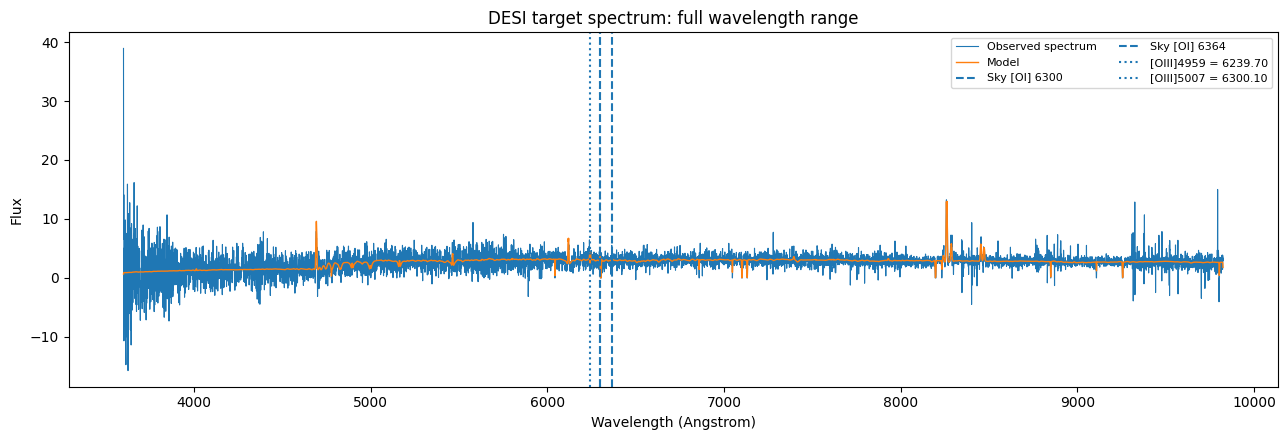

In [28]:
plt.figure(figsize=(13, 4.5))
plt.plot(wave, flux, lw=0.8, label="Observed spectrum")
plt.plot(wave, model, lw=1.0, label="Model")

plt.axvline(6300, ls="--", label="Sky [OI] 6300")
plt.axvline(6364, ls="--", label="Sky [OI] 6364")
plt.axvline(oiii4959_obs, ls=":", label=f"[OIII]4959 = {oiii4959_obs:.2f}")
plt.axvline(oiii5007_obs, ls=":", label=f"[OIII]5007 = {oiii5007_obs:.2f}")

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("DESI target spectrum: full wavelength range")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

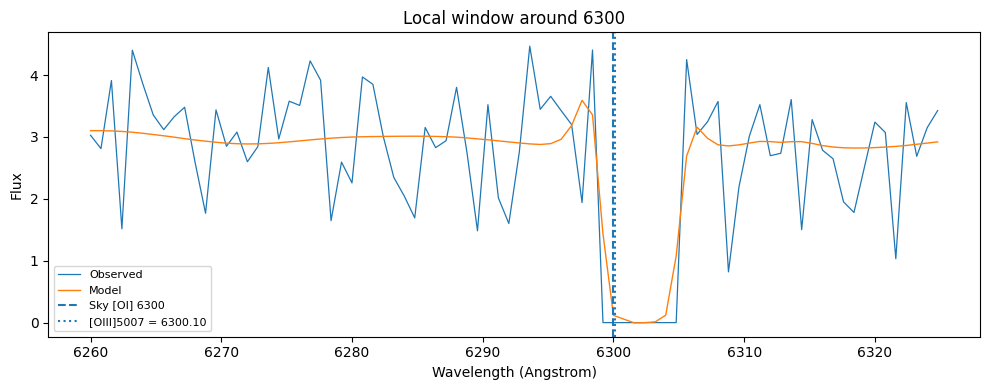

In [29]:
plt.figure(figsize=(10, 4))
m1 = (wave > 6260) & (wave < 6325)

plt.plot(wave[m1], flux[m1], lw=0.9, label="Observed")
plt.plot(wave[m1], model[m1], lw=1.0, label="Model")

plt.axvline(6300, ls="--", label="Sky [OI] 6300")
plt.axvline(oiii5007_obs, ls=":", label=f"[OIII]5007 = {oiii5007_obs:.2f}")

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("Local window around 6300")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

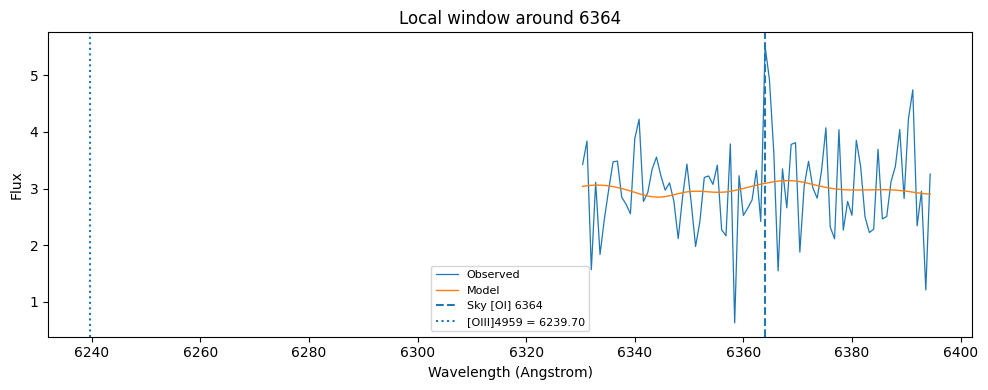

In [30]:
plt.figure(figsize=(10, 4))
m2 = (wave > 6330) & (wave < 6395)

plt.plot(wave[m2], flux[m2], lw=0.9, label="Observed")
plt.plot(wave[m2], model[m2], lw=1.0, label="Model")

plt.axvline(6364, ls="--", label="Sky [OI] 6364")
plt.axvline(oiii4959_obs, ls=":", label=f"[OIII]4959 = {oiii4959_obs:.2f}")

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("Local window around 6364")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [31]:
resid = flux - model
good = (ivar > 0) & (mask == 0)

print("number of good pixels =", good.sum())
print("number of masked pixels =", (mask != 0).sum())

number of good pixels = 7730
number of masked pixels = 51


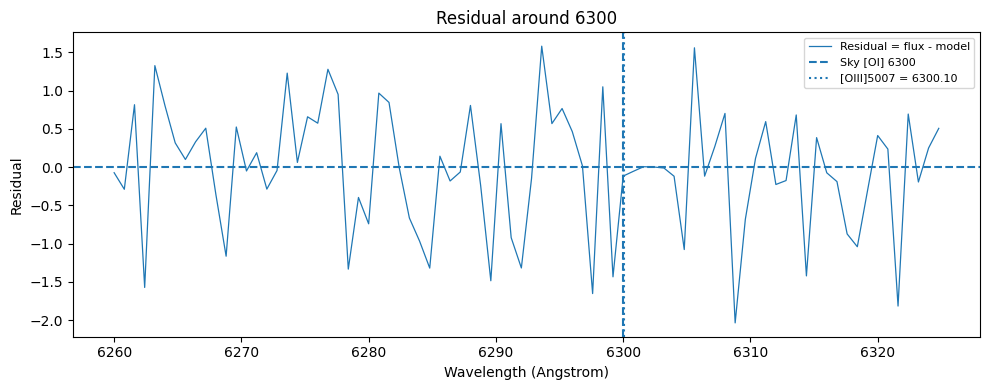

In [32]:
plt.figure(figsize=(10, 4))
m1 = (wave > 6260) & (wave < 6325)

plt.plot(wave[m1], resid[m1], lw=0.9, label="Residual = flux - model")
plt.axhline(0, ls="--")
plt.axvline(6300, ls="--", label="Sky [OI] 6300")
plt.axvline(oiii5007_obs, ls=":", label=f"[OIII]5007 = {oiii5007_obs:.2f}")

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Residual")
plt.title("Residual around 6300")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

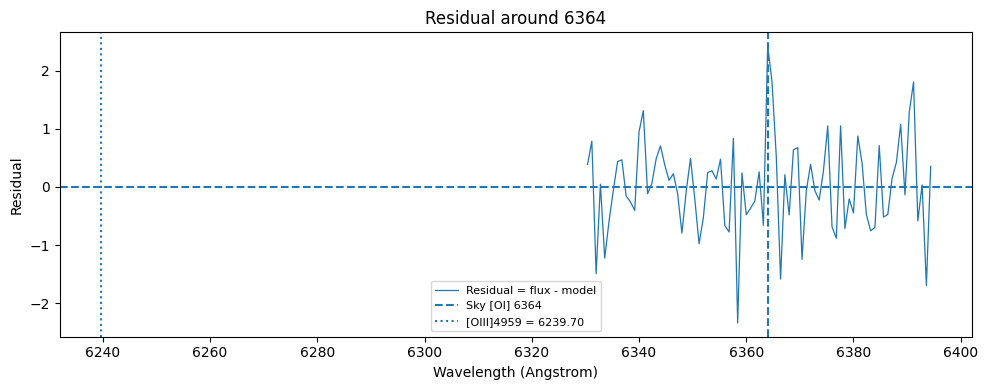

In [33]:
plt.figure(figsize=(10, 4))
m2 = (wave > 6330) & (wave < 6395)

plt.plot(wave[m2], resid[m2], lw=0.9, label="Residual = flux - model")
plt.axhline(0, ls="--")
plt.axvline(6364, ls="--", label="Sky [OI] 6364")
plt.axvline(oiii4959_obs, ls=":", label=f"[OIII]4959 = {oiii4959_obs:.2f}")

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Residual")
plt.title("Residual around 6364")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
err = np.full_like(flux, np.nan, dtype=float)
ok = ivar > 0
err[ok] = 1.0 / np.sqrt(ivar[ok])

print("finite error pixels =", np.isfinite(err).sum())

finite error pixels = 7730


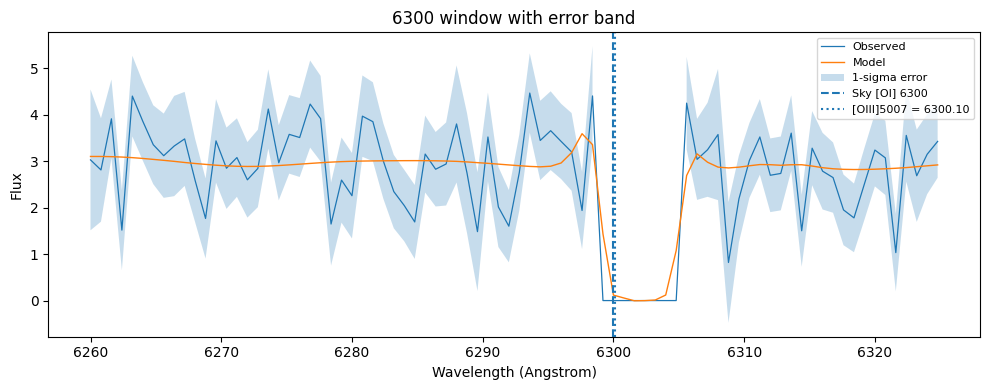

In [35]:
plt.figure(figsize=(10, 4))
m1 = (wave > 6260) & (wave < 6325)

plt.plot(wave[m1], flux[m1], lw=0.9, label="Observed")
plt.plot(wave[m1], model[m1], lw=1.0, label="Model")
plt.fill_between(
    wave[m1],
    flux[m1] - err[m1],
    flux[m1] + err[m1],
    alpha=0.25,
    label="1-sigma error"
)

plt.axvline(6300, ls="--", label="Sky [OI] 6300")
plt.axvline(oiii5007_obs, ls=":", label=f"[OIII]5007 = {oiii5007_obs:.2f}")

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("6300 window with error band")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [36]:
m1 = (wave > 6295) & (wave < 6306)

print("wave in 6300 region:")
print(wave[m1])

print("\nflux in 6300 region:")
print(flux[m1])

print("\nmodel in 6300 region:")
print(model[m1])

print("\nivar in 6300 region:")
print(ivar[m1])

print("\nmask in 6300 region:")
print(mask[m1])

wave in 6300 region:
[6295.2 6296.  6296.8 6297.6 6298.4 6299.2 6300.  6300.8 6301.6 6302.4
 6303.2 6304.  6304.8 6305.6]

flux in 6300 region:
[3.65657139 3.42539215 3.19963813 1.93915939 4.40459394 0.
 0.         0.         0.         0.         0.         0.
 0.         4.24977875]

model in 6300 region:
[ 2.89165831e+00  2.96162152e+00  3.18405366e+00  3.59156466e+00
  3.35620308e+00  1.43370152e+00  1.17760777e-01  5.54294921e-02
 -4.50195000e-03 -1.27933465e-03  1.19080534e-02  1.19731449e-01
  1.07711518e+00  2.69187117e+00]

ivar in 6300 region:
[1.39113033 1.52396154 1.42992735 1.44341779 0.87160712 0.
 0.         0.         0.         0.         0.         0.
 0.         1.00794935]

mask in 6300 region:
[0 0 0 0 0 1 1 1 1 1 1 1 1 0]


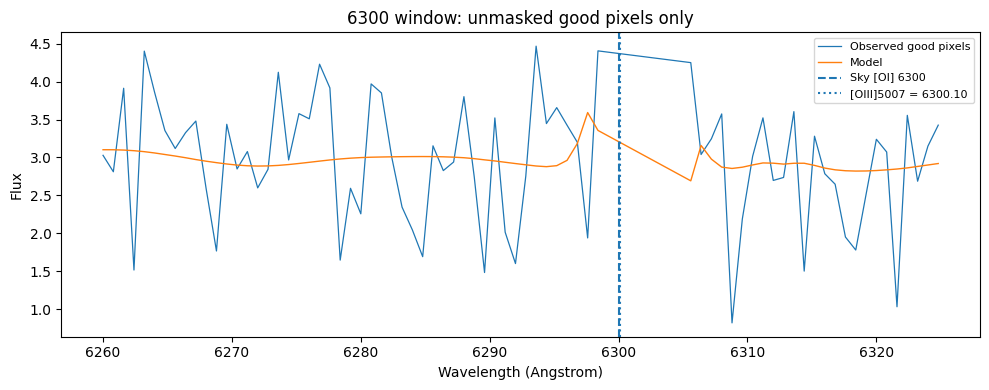

In [37]:
good = (ivar > 0) & (mask == 0)
m1 = (wave > 6260) & (wave < 6325) & good

plt.figure(figsize=(10,4))
plt.plot(wave[m1], flux[m1], lw=0.9, label="Observed good pixels")
plt.plot(wave[m1], model[m1], lw=1.0, label="Model")
plt.axvline(6300, ls="--", label="Sky [OI] 6300")
plt.axvline(oiii5007_obs, ls=":", label=f"[OIII]5007 = {oiii5007_obs:.2f}")
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("6300 window: unmasked good pixels only")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [1]:
z_control = 6330/5007 - 1
print("z_control =", z_control)

z_control = 0.26423007789095276


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

from sparcl.client import SparclClient
from dl import queryClient as qc

client = SparclClient()

print("All imports OK")

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.
All imports OK


In [5]:
z_control = 6330/5007 - 1

query_control = f"""
SELECT TOP 10
    targetid,
    z,
    zwarn,
    spectype,
    mean_fiber_ra,
    mean_fiber_dec,
    healpix,
    ABS(z - ({z_control})) AS dz
FROM desi_dr1.zpix
WHERE survey = 'main'
  AND main_primary = 't'
  AND zwarn = 0
  AND spectype = 'GALAXY'
  AND z BETWEEN 0.25 AND 0.29
ORDER BY dz ASC
"""
result_control = qc.query(sql=query_control)
print(result_control)

targetid,z,zwarn,spectype,mean_fiber_ra,mean_fiber_dec,healpix,dz
39633367796289275,0.2642300299910962,0,GALAXY,106.593537888091,58.41048477083194,7121,4.789985658115725e-08
39633211436827883,0.2642300196107629,0,GALAXY,113.4531910436651,47.64221995010446,6934,5.8280189840775876e-08
39627950999470367,0.2642299987812866,0,GALAXY,206.6608827349032,6.801818270209558,26440,7.91096661512114e-08
39633040162425716,0.2642299821050419,0,GALAXY,249.1788176390547,37.92541871729357,9460,9.578591086967236e-08
39628497668280014,0.2642298956379586,0,GALAXY,268.397629870168,30.70399866682224,32663,1.822529941408746e-07
39628015444953965,0.2642298887619588,0,GALAXY,123.4029314253514,9.59634611072097,22357,1.8912899396594796e-07
39627645129858644,0.264229841853376,0,GALAXY,309.7800807048027,-6.072381030117111,49085,2.3603757676182724e-07
39627888181379581,0.264230321764194,0,GALAXY,48.37845806495955,4.132821679569878,19,2.4387324121244447e-07
39633410670465281,0.2642303308382152,0,GALAXY,187.40577826390

In [6]:
df_control = pd.read_csv(StringIO(result_control))
df_control["oiii5007_obs"] = 5007 * (1 + df_control["z"])
df_control["d_5007_to_6300"] = abs(df_control["oiii5007_obs"] - 6300)

df_control[[
    "targetid", "z", "mean_fiber_ra", "mean_fiber_dec",
    "healpix", "oiii5007_obs", "d_5007_to_6300"
]]

,targetid,z,mean_fiber_ra,mean_fiber_dec,healpix,oiii5007_obs,d_5007_to_6300
0,39633367796289275,0.26423,106.593538,58.410485,7121,6329.999760,29.999760
1,39633211436827883,0.26423,113.453191,47.642220,6934,6329.999708,29.999708
2,39627950999470367,0.26423,206.660883,6.801818,26440,6329.999604,29.999604
3,39633040162425716,0.26423,249.178818,37.925419,9460,6329.999520,29.999520
4,39628497668280014,0.26423,268.397630,30.703999,32663,6329.999087,29.999087
5,39628015444953965,0.26423,123.402931,9.596346,22357,6329.999053,29.999053
6,39627645129858644,0.26423,309.780081,-6.072381,49085,6329.998818,29.998818
7,39627888181379581,0.26423,48.378458,4.132822,19,6330.001221,30.001221
8,39633410670465281,0.26423,187.405778,61.969020,11249,6330.001267,30.001267
9,39627427302869595,0.26423,65.025223,-15.079358,22563,6330.001284,30.001284


In [7]:
control_row = df_control.iloc[0]

ra_c = control_row["mean_fiber_ra"]
dec_c = control_row["mean_fiber_dec"]
z_c = control_row["z"]

print("ra_c =", ra_c)
print("dec_c =", dec_c)
print("z_c =", z_c)

ra_c = 106.593537888091
dec_c = 58.41048477083194
z_c = 0.2642300299910962


In [8]:
constraints_control = {
    "data_release": ["DESI-DR1"],
    "spectype": ["GALAXY"],
    "redshift": [z_c - 0.0005, z_c + 0.0005],
}

found_control = client.find(
    constraints=constraints_control,
    limit=20
)

print(type(found_control))
print("ids =", found_control.ids)
print("n_ids =", len(found_control.ids))

<class 'sparcl.Results.Found'>
ids = ['00017b54-86b2-11ef-a3d8-525400f334e1', '00027959-89f9-11ef-aae7-525400f334e1', '000a13a6-894d-11ef-a082-525400f334e1', '000b03b0-8879-11ef-84eb-525400f334e1', '000eca8d-873b-11ef-a5ee-525400f334e1', '000f203b-874b-11ef-aef1-525400f334e1', '0010b453-883a-11ef-b807-525400f334e1', '0017b8ed-8998-11ef-b48c-525400f334e1', '0017c87a-8892-11ef-964a-525400f334e1', '001c9696-87b4-11ef-bb02-525400f334e1', '001e0e5c-85c8-11ef-9929-525400f334e1', '001e2f4c-88db-11ef-b740-525400f334e1', '001f1f00-87cf-11ef-947c-525400f334e1', '001fa571-8753-11ef-8b7f-525400f334e1', '001faa2d-8b57-11ef-afaf-525400f334e1', '0020342f-86c5-11ef-87bf-525400f334e1', '0021d4c5-8803-11ef-856f-525400f334e1', '00244a00-87df-11ef-9768-525400f334e1', '00252aa5-89dd-11ef-8de5-525400f334e1', '0026f772-8832-11ef-8610-525400f334e1']
n_ids = 20


In [9]:
ids_all_control = found_control.ids

ret_all_control = client.retrieve(
    uuid_list=ids_all_control,
    include=["sparcl_id", "ra", "dec", "redshift", "spectype", "data_release"]
)

print("number of returned records =", len(ret_all_control.records))

number of returned records = 20


In [10]:
rows = []
for rec in ret_all_control.records:
    rows.append({
        "sparcl_id": getattr(rec, "sparcl_id", None),
        "ra": getattr(rec, "ra", np.nan),
        "dec": getattr(rec, "dec", np.nan),
        "redshift": getattr(rec, "redshift", np.nan),
        "spectype": getattr(rec, "spectype", None),
        "data_release": getattr(rec, "data_release", None),
    })

cand_control = pd.DataFrame(rows)

cand_control["sep_deg"] = np.sqrt(
    ((cand_control["ra"] - ra_c) * np.cos(np.deg2rad(dec_c)))**2 +
    (cand_control["dec"] - dec_c)**2
)
cand_control["dz"] = abs(cand_control["redshift"] - z_c)

cand_control = cand_control.sort_values(["sep_deg", "dz"]).reset_index(drop=True)
cand_control.head(10)

,sparcl_id,ra,dec,redshift,spectype,data_release,sep_deg,dz
0,000a13a6-894d-11ef-a082-525400f334e1,112.557126,74.956917,0.263739,GALAXY,DESI-DR1,16.838741,0.000491
1,001e0e5c-85c8-11ef-9929-525400f334e1,180.756808,68.713068,0.263746,GALAXY,DESI-DR1,40.191840,0.000484
2,000b03b0-8879-11ef-84eb-525400f334e1,152.779355,6.422628,0.264664,GALAXY,DESI-DR1,57.341639,0.000434
3,0010b453-883a-11ef-b807-525400f334e1,128.256097,2.032219,0.264623,GALAXY,DESI-DR1,57.508909,0.000393
4,00244a00-87df-11ef-9768-525400f334e1,214.842346,32.007741,0.264265,GALAXY,DESI-DR1,62.549547,0.000035
5,001faa2d-8b57-11ef-afaf-525400f334e1,144.661840,-4.850532,0.264124,GALAXY,DESI-DR1,66.329575,0.000106
6,00027959-89f9-11ef-aae7-525400f334e1,156.508716,-3.594528,0.264128,GALAXY,DESI-DR1,67.292577,0.000102
7,00252aa5-89dd-11ef-8de5-525400f334e1,229.518350,35.362099,0.264158,GALAXY,DESI-DR1,68.392399,0.000072
8,0017c87a-8892-11ef-964a-525400f334e1,241.798294,54.522265,0.264107,GALAXY,DESI-DR1,70.930963,0.000123
9,00017b54-86b2-11ef-a3d8-525400f334e1,37.583090,-3.870274,0.264302,GALAXY,DESI-DR1,72.011784,0.000072


In [11]:
best_control = cand_control.iloc[0]
print(best_control)

sparcl_id       000a13a6-894d-11ef-a082-525400f334e1
ra                                        112.557126
dec                                        74.956917
redshift                                    0.263739
spectype                                      GALAXY
data_release                                DESI-DR1
sep_deg                                    16.838741
dz                                          0.000491
Name: 0, dtype: object


In [12]:
best_control_id = [best_control["sparcl_id"]]

ret_control = client.retrieve(
    uuid_list=best_control_id,
    include=[
        "sparcl_id", "flux", "wavelength", "model",
        "ivar", "mask", "redshift", "spectype", "ra", "dec"
    ]
)

print("number of returned records =", len(ret_control.records))
print(ret_control.records[0])

number of returned records = 1
{'redshift': 0.26373900970092506, 'ra': 112.5571262924073, 'spectype': 'GALAXY', 'sparcl_id': '000a13a6-894d-11ef-a082-525400f334e1', 'dec': 74.95691698052137, 'mask': array([0, 0, 0, ..., 0, 0, 0], dtype=int64), 'ivar': array([0.02915452, 0.0225259 , 0.02207877, ..., 5.50200462, 6.89708042,
       7.04857445]), 'model': array([1.4507724 , 1.94108355, 2.05984592, ..., 2.66473842, 2.53671813,
       1.85538256]), 'flux': array([ 9.89828396, -1.48645329,  3.40844846, ...,  2.38308382,
        2.60878158,  2.52887869]), 'wavelength': array([3600. , 3600.8, 3601.6, ..., 9822.4, 9823.2, 9824. ]), '_dr': 'DESI-DR1'}


In [13]:
rec_control = ret_control.records[0]

wave_c = np.array(rec_control.wavelength)
flux_c = np.array(rec_control.flux)
model_c = np.array(rec_control.model)
ivar_c = np.array(rec_control.ivar)
mask_c = np.array(rec_control.mask)

z_c2 = rec_control.redshift
oiii5007_obs_c = 5007 * (1 + z_c2)

print("z_control =", z_c2)
print("[OIII]5007_obs_control =", oiii5007_obs_c)
print("distance to 6300 =", abs(oiii5007_obs_c - 6300))

z_control = 0.26373900970092506
[OIII]5007_obs_control = 6327.541221572532
distance to 6300 = 27.541221572531867


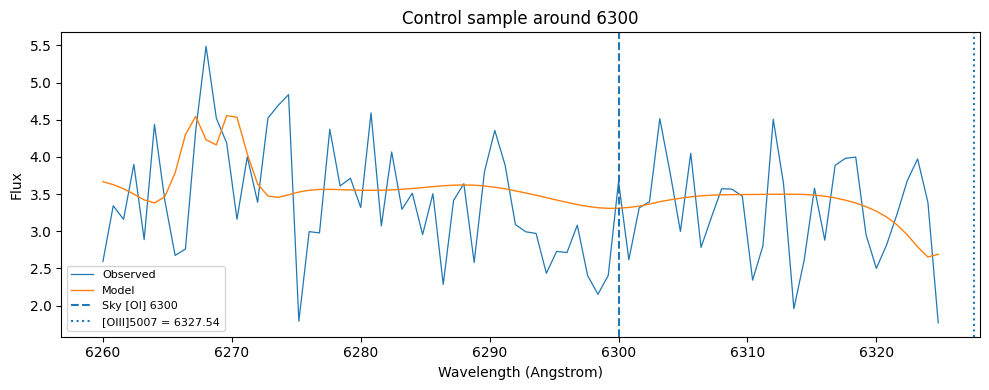

In [14]:
plt.figure(figsize=(10, 4))
m_c = (wave_c > 6260) & (wave_c < 6325)

plt.plot(wave_c[m_c], flux_c[m_c], lw=0.9, label="Observed")
plt.plot(wave_c[m_c], model_c[m_c], lw=1.0, label="Model")
plt.axvline(6300, ls="--", label="Sky [OI] 6300")
plt.axvline(oiii5007_obs_c, ls=":", label=f"[OIII]5007 = {oiii5007_obs_c:.2f}")

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("Control sample around 6300")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
m_c2 = (wave_c > 6295) & (wave_c < 6306)

print("wave in 6300 region:")
print(wave_c[m_c2])

print("\nflux in 6300 region:")
print(flux_c[m_c2])

print("\nivar in 6300 region:")
print(ivar_c[m_c2])

print("\nmask in 6300 region:")
print(mask_c[m_c2])

wave in 6300 region:
[6295.2 6296.  6296.8 6297.6 6298.4 6299.2 6300.  6300.8 6301.6 6302.4
 6303.2 6304.  6304.8 6305.6]

flux in 6300 region:
[2.72958088 2.71409893 3.08226514 2.40476131 2.15335274 2.40609312
 3.66831565 2.61796546 3.31479096 3.39671659 4.51389074 3.78783822
 2.99756217 4.0483799 ]

ivar in 6300 region:
[2.81942892 2.55599093 2.74130678 2.759902   2.74570489 2.64367771
 2.44479299 2.1193161  1.5966866  1.11066413 1.57482159 2.60008454
 2.85806441 2.86196566]

mask in 6300 region:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
